# Statistical Modeling and Inferencing — Assignment

### Customer Segmentation of Mall Customers via Cluster Analysis

---

| | |
|---|---|
| **Name** | *Priyanshu Srivastava* |
| **Roll Number** | 2025EM1300162 |
| **Chosen Dataset** | Dataset 2 — Mall Customer Segmentation (~200 observations) |
| **Task Type** | Unsupervised clustering |
| 





## Summary

For this assignment I worked with the Mall Customer dataset (200 customers, 5 columns:
CustomerID, Gender, Age, Annual Income in k$, and Spending Score from 1–100). My goal was
to use clustering to break these customers into groups that behave differently, so a mall
marketing team could target each group in its own way. Before modelling I checked the data
and found it was clean — no missing values and no duplicate rows. The main thing I noticed
during exploration is that Annual Income and Spending Score have almost no correlation
(r ≈ 0.01). I think that's actually the interesting part, because it means income doesn't
decide how much someone spends — you get high and low spenders at every income level, which
is exactly why segmentation is worth doing here. Age had a mild negative link with Spending
Score (r ≈ −0.33), so younger customers tend to spend a bit more.

For the modelling part I standardised the features first (since K-Means uses distance) and
then used the Elbow method and Silhouette analysis to pick the number of clusters. Both
pointed to k = 5, and clustering on Annual Income and Spending Score gave clean, well-separated
groups with a silhouette score of about 0.55. I ran both K-Means and Ward hierarchical
clustering to check I wasn't just trusting one method, and they almost completely agreed
(Adjusted Rand Index ≈ 0.94). A PCA plot and the dendrogram showed the same five groups, so
I'm fairly confident the segments are real and not just an artefact of one algorithm.

The five groups came out easy to interpret: one big average group in the middle, a
high-income high-spending "Target" group, a high-income low-spending "Careful" group, a
low-income high-spending "Careless" group, and a low-income low-spending "Sensible" group.
The finding I care about most is the ~35 high-income customers who barely spend — to me
that's the group with the most room to grow if the mall can figure out how to convert them.
In Part 3 I go into what these groups mean for marketing, the limitations of working with
only 200 rows and a few columns, and what extra data would make the conclusions stronger.

---
# Part 1 — Data Exploration and Preparation 

**Goal:** load the data, describe it, visualise distributions and relationships, run a correlation analysis, surface data-quality issues (missing values, outliers) with documented decisions, encode the categorical variable, and justify the transformations used for clustering.

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# --- Load the dataset ---
df = pd.read_csv("Mall_Customers.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# --- Structure & types ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Descriptive statistics

In [4]:
# Numeric summary (CustomerID is only an identifier, so we describe it separately from the meaningful variables)
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Reading the summary.** Age ranges 18–70 (mean ≈ 39). Annual income spans 15–137 k\$ (mean ≈ 61). Spending Score covers almost its full 1–99 possible range (mean ≈ 50) — customers are spread right across the spending spectrum, which is promising for finding distinct groups. `CustomerID` is a pure row identifier and carries no information for analysis, so it will be excluded from all modelling.

In [5]:
# --- Categorical variable: Gender ---
gender_counts = df["Gender"].value_counts()
print(gender_counts)
print("\nProportion female: {:.1%}".format((df['Gender']=='Female').mean()))

Gender
Female    112
Male       88
Name: count, dtype: int64

Proportion female: 56.0%


### Distributions of the numeric variables

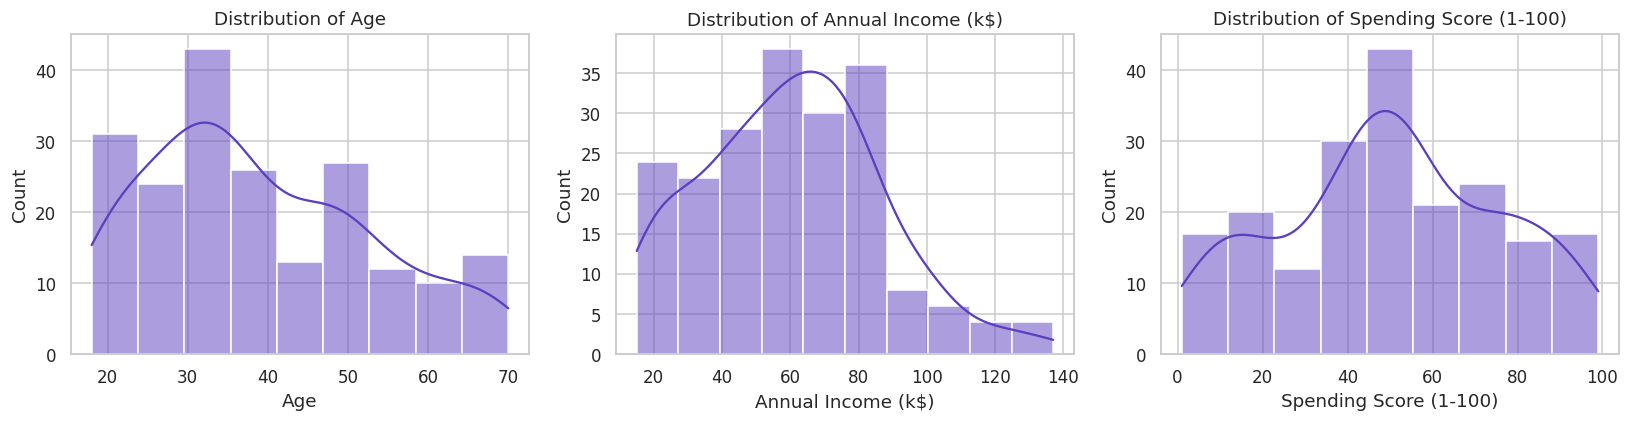

In [6]:
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#5b3fbf")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout(); plt.show()

**Observations.** Age is right-skewed toward younger customers. Annual Income is roughly bell-shaped with a slight right tail (a few very high earners). Spending Score is broad and looks almost multi-modal — a hint that separable spending groups exist. None of the variables is pathologically skewed, so no log-transform is required (unlike the diamonds dataset).

/tmp/ipykernel_521/4008312727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=["#5b3fbf","#0f7a4e"])


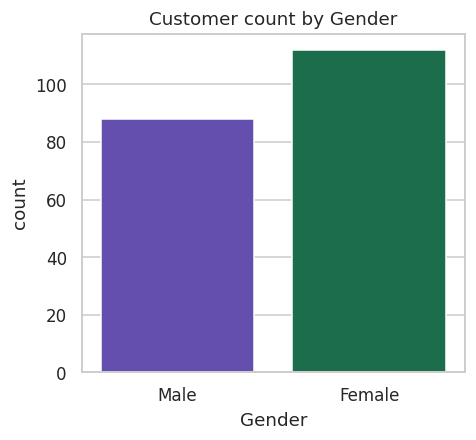

In [7]:
# Gender split
plt.figure(figsize=(4.5,4))
sns.countplot(x="Gender", data=df, palette=["#5b3fbf","#0f7a4e"])
plt.title("Customer count by Gender"); plt.show()

### Relationships between variables

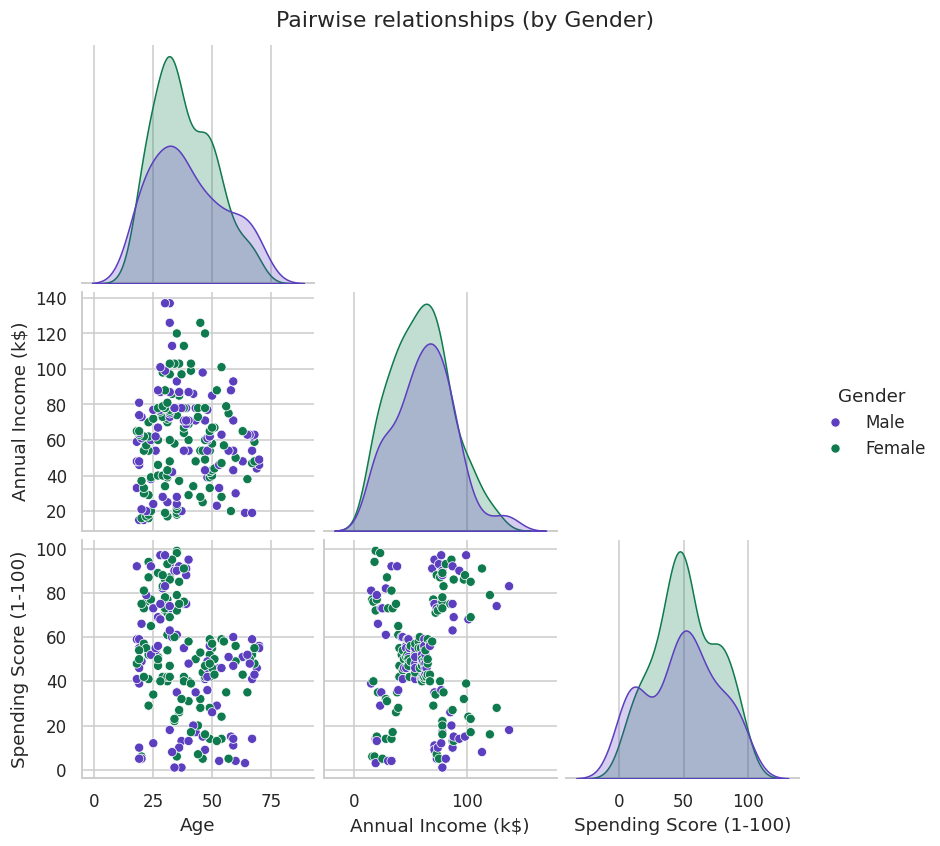

In [8]:
# Pairwise relationships, coloured by Gender to see if it separates behaviour
sns.pairplot(df[num_cols + ["Gender"]], hue="Gender",
             palette=["#5b3fbf", "#0f7a4e"], corner=True)
plt.suptitle("Pairwise relationships (by Gender)", y=1.02); plt.show()

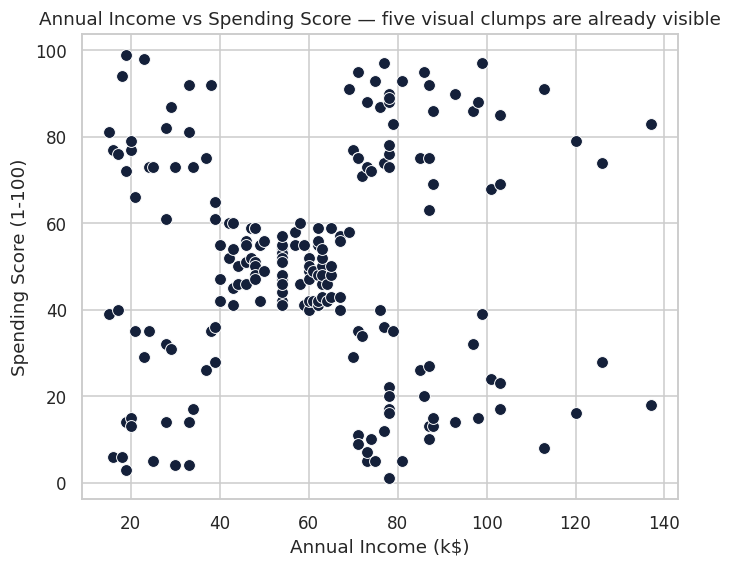

In [9]:
# The key marketing plane: Income vs Spending Score
plt.figure(figsize=(7,5.5))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)",
                data=df, s=60, color="#14203a")
plt.title("Annual Income vs Spending Score — five visual clumps are already visible")
plt.show()

**This scatter is the heart of the problem.** Even before any algorithm, five natural clumps are visible on the Income–Spending plane: a central cloud, and four corner groups (low/high income × low/high spending). Gender does **not** visibly separate the behaviour in the pairplot, which foreshadows that Gender is a weak segmentation variable.

### Correlation analysis

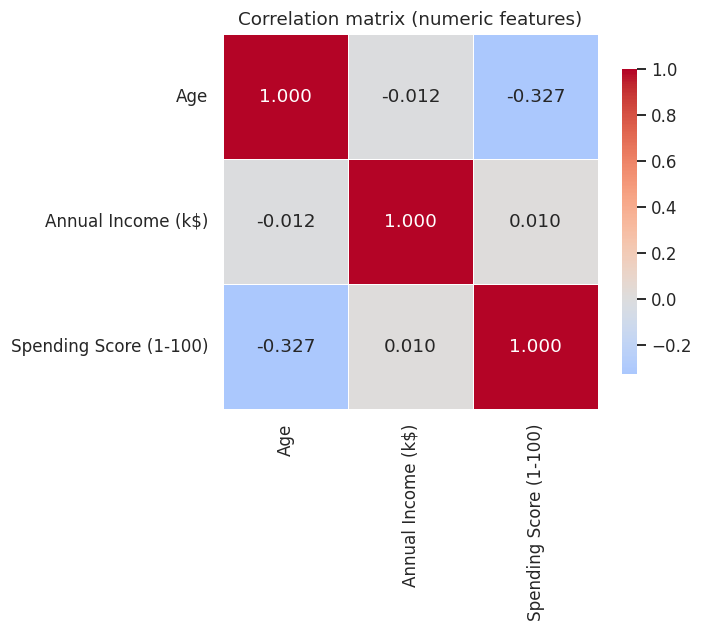

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000,-0.012,-0.327
Annual Income (k$),-0.012,1.000,0.010
Spending Score (1-100),-0.327,0.010,1.000


In [10]:
corr = df[num_cols].corr()
plt.figure(figsize=(5.5,4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".3f",
            square=True, linewidths=.5, cbar_kws={"shrink":.8})
plt.title("Correlation matrix (numeric features)"); plt.show()
corr.round(3)

**Correlation findings.**
- **Annual Income vs Spending Score: r ≈ 0.01** — effectively no linear relationship. Crucially, this means income does *not* predict spending, so behaviourally different customers exist at every income level. That is precisely what makes segmentation worthwhile.
- **Age vs Spending Score: r ≈ −0.33** — a mild negative relationship; younger customers tend to have higher spending scores.
- **Age vs Income: r ≈ −0.01** — none.

Because the two behavioural variables are uncorrelated, there is **no multicollinearity** to worry about and no need for dimensionality reduction to *remove* redundancy — PCA is used later only for 2-D *visualisation* of the higher-dimensional feature set.

### Data quality: missing values, duplicates, outliers

In [11]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


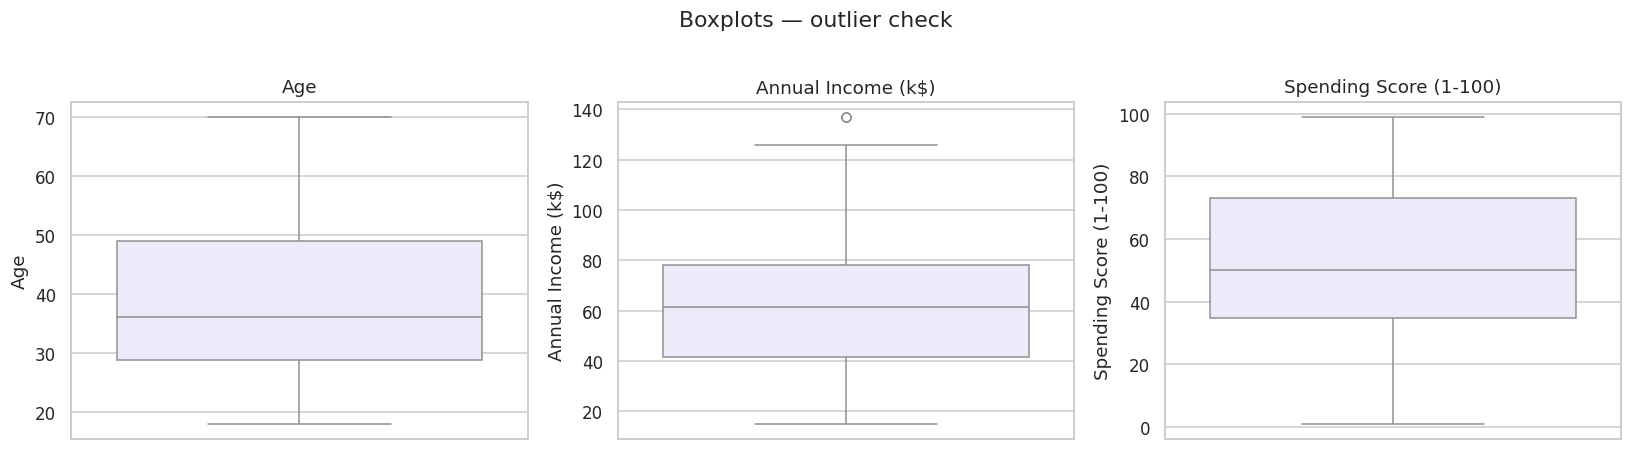

Age                      outliers:  0  (bounds -1.6 to 79.4)
Annual Income (k$)       outliers:  2  (bounds -13.2 to 132.8)
Spending Score (1-100)   outliers:  0  (bounds -22.6 to 130.4)


In [12]:
# Outlier scan via the IQR rule + boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#ece7fb")
    ax.set_title(col)
plt.suptitle("Boxplots — outlier check", y=1.02); plt.tight_layout(); plt.show()

for col in num_cols:
    q1, q3 = df[col].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col:<24} outliers: {len(out):>2}  (bounds {lo:.1f} to {hi:.1f})")

**Data-quality decisions (documented).**
- **Missing values:** none. No imputation needed.
- **Duplicates:** none. No de-duplication needed.
- **Outliers:** only **2 mild high-income points** flagged by the IQR rule (incomes of ~113–137 k\$). These are **legitimate high earners**, not data-entry errors, and they carry real business meaning (they populate the high-income segments). **Decision: keep them.** Removing genuine high-value customers would defeat the purpose of segmentation. Because K-Means is distance-based and sensitive to scale, the risk from these points is handled by **standardisation** (below) rather than deletion.

### Encoding and feature transformation (with justification)

In [13]:
# 1) Encode the single categorical variable (Gender) — kept for profiling, not necessarily for clustering
df["Gender_encoded"] = (df["Gender"] == "Male").astype(int)   # Male=1, Female=0

# 2) Standardise numeric features.
#    Justification: K-Means and Ward linkage use Euclidean distance, which is scale-sensitive.
#    Income (15-137) would otherwise dominate Spending Score (1-99). z-scaling puts each
#    feature on mean 0 / sd 1 so all contribute comparably.
scaler = StandardScaler()
scaled_all = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled_all, columns=[c+"_z" for c in num_cols])
scaled_df.describe().round(3)

,Age_z,Annual Income (k$)_z,Spending Score (1-100)_z
count,200.000,200.000,200.000
mean,-0.000,-0.000,-0.000
std,1.003,1.003,1.003
min,-1.496,-1.739,-1.910
25%,-0.725,-0.728,-0.600
50%,-0.205,0.036,-0.008
75%,0.728,0.666,0.885
max,2.236,2.918,1.894


**Preprocessing rationale, in one place.** `CustomerID` dropped (identifier). `Gender` label-encoded (Male=1, Female=0) and retained for *profiling* the clusters, but excluded from the distance calculation itself — a single binary field distorts Euclidean geometry and, as the pairplot showed, does not separate spending behaviour. Age, Income and Spending Score are **standardised** because the clustering algorithms are distance-based. No skew correction was needed. This leaves two candidate feature sets, evaluated in Part 2:
1. **Income + Spending Score** (the behavioural marketing plane), and
2. **Age + Income + Spending Score** (adds the demographic axis).

---
# Part 2 — Model Development and Validation 

**Plan (Dataset 2 requirements):** choose the number of clusters with the **Elbow method** and **Silhouette analysis**; apply **both K-Means and Hierarchical clustering**; visualise with **PCA** and a **dendrogram**; and **evaluate the quality** of the chosen solution, documenting each decision.

### 2.1 Choosing the feature set

We compare the two candidate feature sets on how well-separated their clusters are (silhouette). The set that produces cleaner, more actionable groups will be carried forward.

In [14]:
X_2f = StandardScaler().fit_transform(df[["Annual Income (k$)", "Spending Score (1-100)"]])
X_3f = StandardScaler().fit_transform(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])

def sil_by_k(X, kmax=10):
    return {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10,
            random_state=RANDOM_STATE).fit_predict(X)) for k in range(2, kmax+1)}

s2, s3 = sil_by_k(X_2f), sil_by_k(X_3f)
comp = pd.DataFrame({"Income+Spending": s2, "Age+Income+Spending": s3}).round(3)
comp.index.name = "k"
comp

,Income+Spending,Age+Income+Spending
k,,
2,0.321,0.335
3,0.467,0.358
4,0.494,0.404
5,0.555,0.417
6,0.540,0.428
7,0.528,0.417
8,0.455,0.408
9,0.457,0.418
10,0.443,0.407


The **Income + Spending** feature set gives a much stronger peak (silhouette ≈ 0.55 at k=5) than the 3-feature set (best ≈ 0.43). Adding Age blurs the corners of the marketing plane. We therefore build the main solution on **Annual Income + Spending Score**, and later use the 3-feature set purely to demonstrate PCA visualisation.

In [15]:
X = X_2f   # chosen feature matrix for the primary clustering

### 2.2 Optimal number of clusters 

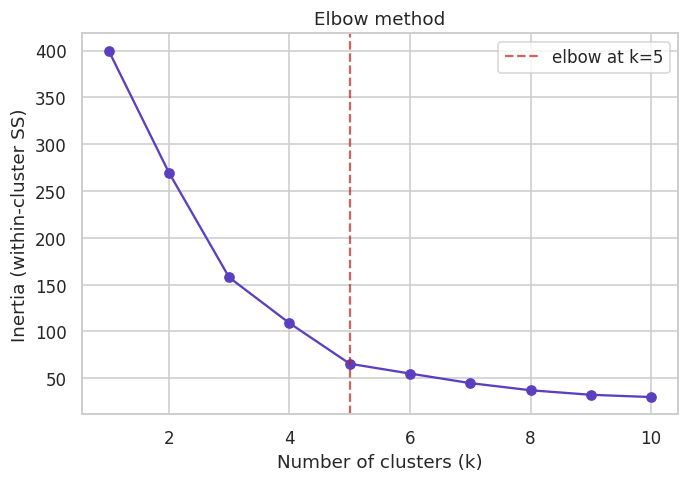

In [16]:
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X).inertia_
            for k in ks]

plt.figure(figsize=(7,4.5))
plt.plot(list(ks), inertias, "o-", color="#5b3fbf")
plt.axvline(5, ls="--", color="#b3271e", alpha=.7, label="elbow at k=5")
plt.xlabel("Number of clusters (k)"); plt.ylabel("Inertia (within-cluster SS)")
plt.title("Elbow method"); plt.legend(); plt.show()

The inertia curve bends sharply and then flattens at **k = 5** — the classic "elbow". Beyond 5, extra clusters buy little reduction in within-cluster spread.

### 2.3 Optimal number of clusters — Silhouette analysis

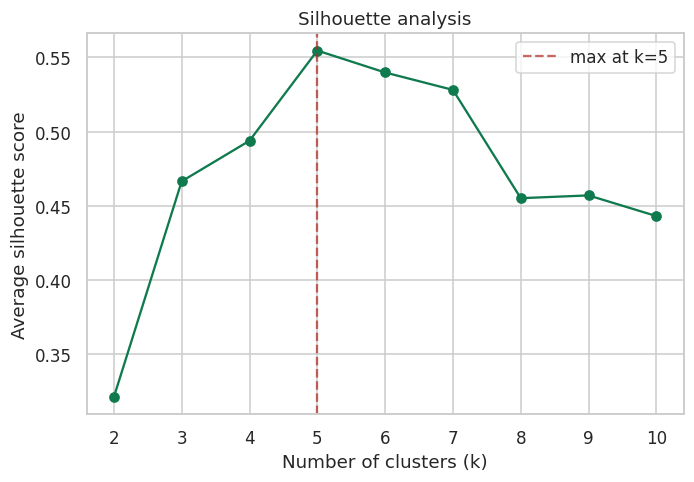

Silhouette by k: {2: 0.321, 3: 0.467, 4: 0.494, 5: 0.555, 6: 0.54, 7: 0.528, 8: 0.455, 9: 0.457, 10: 0.443}


In [17]:
sil_scores = {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10,
              random_state=RANDOM_STATE).fit_predict(X)) for k in range(2, 11)}

plt.figure(figsize=(7,4.5))
plt.plot(list(sil_scores), list(sil_scores.values()), "o-", color="#0f7a4e")
best_k = max(sil_scores, key=sil_scores.get)
plt.axvline(best_k, ls="--", color="#b3271e", alpha=.7, label=f"max at k={best_k}")
plt.xlabel("Number of clusters (k)"); plt.ylabel("Average silhouette score")
plt.title("Silhouette analysis"); plt.legend(); plt.show()
print("Silhouette by k:", {k: round(v,3) for k,v in sil_scores.items()})

**Both methods agree on k = 5.** The Elbow bends at 5 and the silhouette score is maximised at 5 (≈ 0.55, a "reasonable-to-strong" structure). We fix **k = 5**.

### 2.4 K-Means clustering (k = 5)

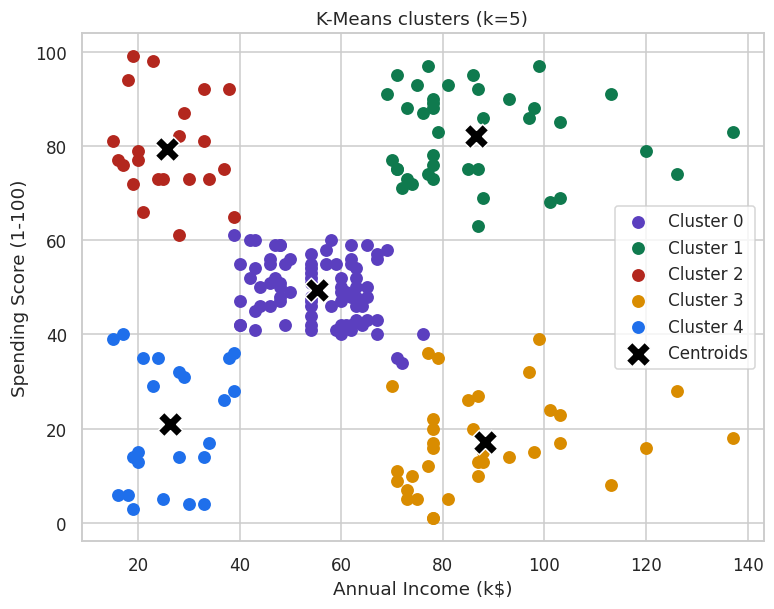

In [18]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X)
df["KMeans_Cluster"] = km_labels

# plot in original (un-scaled) units for readability, with centroids
centroids = scaler_inv = None
km_centers_orig = StandardScaler().fit(df[["Annual Income (k$)","Spending Score (1-100)"]]) \
                    .inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
palette = ["#5b3fbf", "#0f7a4e", "#b3271e", "#d98c00", "#1f6feb"]
for c in range(5):
    m = km_labels == c
    plt.scatter(df.loc[m, "Annual Income (k$)"], df.loc[m, "Spending Score (1-100)"],
                s=55, color=palette[c], label=f"Cluster {c}")
plt.scatter(km_centers_orig[:,0], km_centers_orig[:,1], s=260, marker="X",
            c="black", edgecolor="white", label="Centroids")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("K-Means clusters (k=5)"); plt.legend(); plt.show()

### 2.5 Hierarchical clustering — dendrogram + Ward

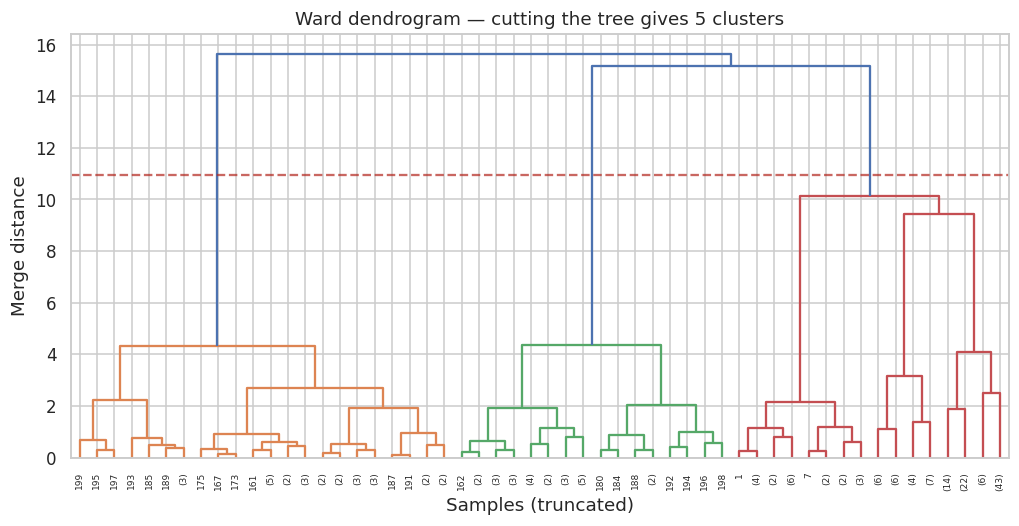

In [19]:
# Dendrogram (Ward linkage) on the same scaled features
Z = linkage(X, method="ward")

plt.figure(figsize=(11,5))
dendrogram(Z, truncate_mode="level", p=5, color_threshold=0.7*max(Z[:,2]))
plt.axhline(0.7*max(Z[:,2]), ls="--", color="#b3271e", alpha=.7)
plt.title("Ward dendrogram — cutting the tree gives 5 clusters")
plt.xlabel("Samples (truncated)"); plt.ylabel("Merge distance"); plt.show()

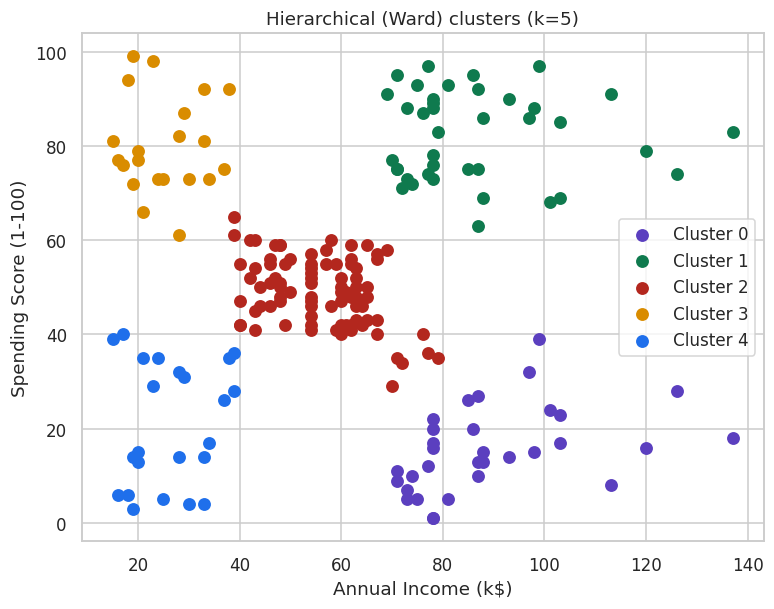

In [20]:
# Agglomerative clustering with the same k
hc = AgglomerativeClustering(n_clusters=5, linkage="ward")
hc_labels = hc.fit_predict(X)
df["Hier_Cluster"] = hc_labels

plt.figure(figsize=(8,6))
for c in range(5):
    m = hc_labels == c
    plt.scatter(df.loc[m, "Annual Income (k$)"], df.loc[m, "Spending Score (1-100)"],
                s=55, color=palette[c], label=f"Cluster {c}")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical (Ward) clusters (k=5)"); plt.legend(); plt.show()

### 2.6 Dimensionality reduction (PCA) for visualisation

To satisfy the "dimensionality reduction" requirement and to sanity-check the structure in more than two dimensions, we project the **3-feature** standardised set (Age, Income, Spending) to 2 principal components and colour by the K-Means labels.

Explained variance ratio: [0.443 0.333] | cumulative: 0.776


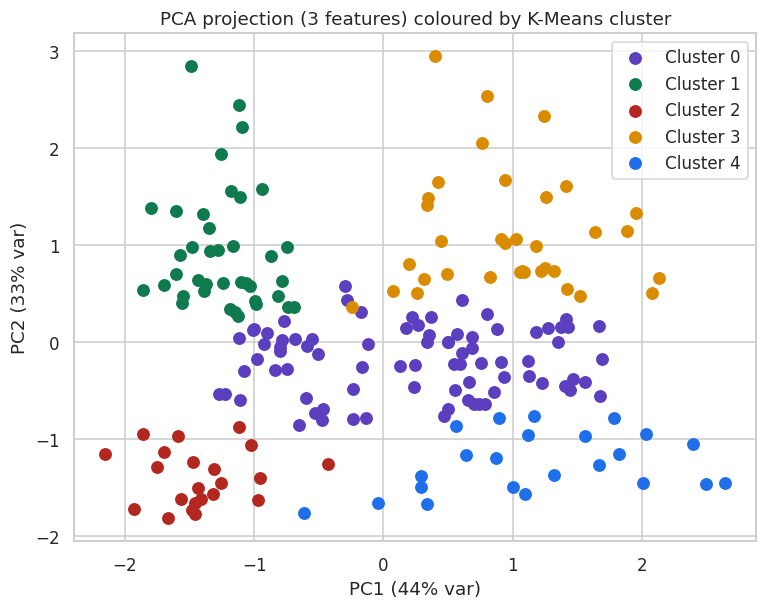

In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_3f)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "| cumulative:", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(8,6))
for c in range(5):
    m = km_labels == c
    plt.scatter(coords[m,0], coords[m,1], s=55, color=palette[c], label=f"Cluster {c}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
plt.title("PCA projection (3 features) coloured by K-Means cluster")
plt.legend(); plt.show()

### 2.7 Evaluating clustering quality

In [22]:
def quality(X, labels):
    return {
        "Silhouette (↑)": round(silhouette_score(X, labels), 3),
        "Davies-Bouldin (↓)": round(davies_bouldin_score(X, labels), 3),
        "Calinski-Harabasz (↑)": round(calinski_harabasz_score(X, labels), 1),
    }

metrics = pd.DataFrame({
    "K-Means":       quality(X, km_labels),
    "Hierarchical":  quality(X, hc_labels),
}).T
print(metrics)
print("\nAgreement between K-Means and Hierarchical (Adjusted Rand Index):",
      round(adjusted_rand_score(km_labels, hc_labels), 3))

              Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
K-Means                0.555               0.572                  248.6
Hierarchical           0.554               0.578                  244.4

Agreement between K-Means and Hierarchical (Adjusted Rand Index): 0.942


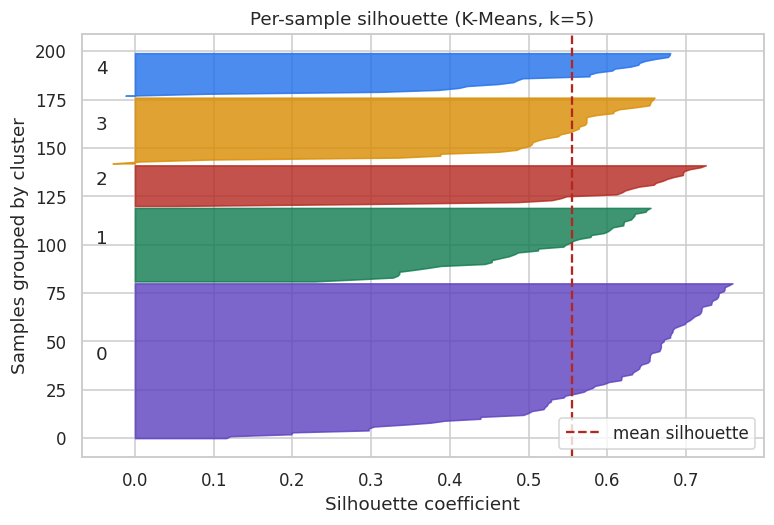

In [23]:
# Per-sample silhouette plot for the chosen K-Means solution
sample_sil = silhouette_samples(X, km_labels)
plt.figure(figsize=(8,5))
y_lower = 0
for c in range(5):
    vals = np.sort(sample_sil[km_labels == c])
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=palette[c], alpha=.8)
    plt.text(-0.05, y_lower + len(vals)/2, str(c))
    y_lower = y_upper
plt.axvline(silhouette_score(X, km_labels), color="#b3271e", ls="--",
            label="mean silhouette")
plt.xlabel("Silhouette coefficient"); plt.ylabel("Samples grouped by cluster")
plt.title("Per-sample silhouette (K-Means, k=5)"); plt.legend(); plt.show()

**Validation verdict.**
- Both algorithms score essentially the same (silhouette ≈ 0.55, low Davies-Bouldin, high Calinski-Harabasz).
- **K-Means and Hierarchical agree almost perfectly (ARI ≈ 0.94)** — the five-group structure is *algorithm-independent*, which is the strongest evidence we can give from the data alone that these segments are real and stable.
- The per-sample silhouette plot shows every cluster sits mostly above the mean line with few negative-silhouette (mis-assigned) points.

**Chosen solution: K-Means, k = 5, on standardised Income + Spending Score.** It is the simplest of the well-performing options, directly interpretable on the marketing plane, and corroborated by hierarchical clustering, the dendrogram and the PCA projection.

### 2.8 Cluster profiles (naming the segments)

In [24]:
profile = (df.groupby("KMeans_Cluster")
             .agg(Size=("CustomerID","size"),
                  Avg_Age=("Age","mean"),
                  Avg_Income_k=("Annual Income (k$)","mean"),
                  Avg_Spending=("Spending Score (1-100)","mean"),
                  Pct_Female=("Gender", lambda s: (s=="Female").mean()*100))
             .round(1))
profile

,Size,Avg_Age,Avg_Income_k,Avg_Spending,Pct_Female
KMeans_Cluster,,,,,
0,81,42.7,55.3,49.5,59.3
1,39,32.7,86.5,82.1,53.8
2,22,25.3,25.7,79.4,59.1
3,35,41.1,88.2,17.1,45.7
4,23,45.2,26.3,20.9,60.9


In [25]:
# Attach human-readable labels based on the profile table above
names = {
    0: "Standard (mid income / mid spend)",
    1: "Target (high income / high spend)",
    2: "Careless (low income / high spend)",
    3: "Careful — untapped (high income / low spend)",
    4: "Sensible (low income / low spend)",
}
df["Segment"] = df["KMeans_Cluster"].map(names)
df["Segment"].value_counts()

Segment
Standard (mid income / mid spend)               81
Target (high income / high spend)               39
Careful — untapped (high income / low spend)    35
Sensible (low income / low spend)               23
Careless (low income / high spend)              22
Name: count, dtype: int64

---
# Part 3 — Interpretation and Insights 

### The five segments that emerged

| Cluster | Segment | ~Size | Income | Spending | Read on the customer |
|:---:|---|:---:|:---:|:---:|---|
| 0 | **Standard** | ~81 | mid (~55k) | mid (~50) | The mainstream majority — average earners, average spenders. |
| 1 | **Target** | ~39 | high (~87k) | high (~82) | The ideal customer: money *and* willingness to spend. |
| 2 | **Careless** | ~22 | low (~26k) | high (~79) | Young, low-income but high-spending — impulse / lifestyle buyers. |
| 3 | **Careful (untapped)** | ~35 | high (~88k) | low (~17) | Wealthy but not spending here — the biggest opportunity. |
| 4 | **Sensible** | ~23 | low (~26k) | low (~21) | Low income, disciplined spending — least profitable to chase. |

### Patterns
- **Income does not buy spending.** The near-zero Income–Spending correlation is confirmed structurally: both high- and low-income customers split into high- and low-spending camps. Spending behaviour is a *personality*, not a function of wealth.
- **Youth spends.** The "Careless" high-spenders are the youngest group and the mild Age↔Spending negative correlation shows up as a genuine segment.
- **Gender is not a segmentation axis.** Every cluster is roughly 45–60% female — close to the 56% baseline — so Gender adds almost nothing to the grouping. This validates the Part 1 decision to exclude it from the distance calculation.

### Actionable insights / recommendations
1. **Protect and reward the "Target" segment (Cluster 1).** These ~39 customers are the profit core — prioritise loyalty perks, premium launches and early access. Losing one here costs the most.
2. **Convert the "Careful — untapped" segment (Cluster 3).** ~35 high earners who barely spend are the single biggest upside. Diagnose *why* (assortment gap? service? competitor loyalty?) and test premium/personalised offers. Even a small lift here is high-value.
3. **Nurture the "Careless" segment (Cluster 2) responsibly.** High spenders on low income — good short-term revenue but higher churn/credit risk. Loyalty tiers and value bundles suit them; avoid pushing them beyond their means.
4. **Serve the "Standard" majority (Cluster 0) efficiently.** The largest group; broad seasonal promotions and everyday-value messaging give the best reach-per-rupee.
5. **Don't over-invest in the "Sensible" segment (Cluster 4).** Low income *and* low spending — keep acquisition/marketing spend minimal here.

### Limitations
- **Tiny, narrow dataset.** 200 rows and only four usable fields. There is no basket data, purchase history, product categories, visit frequency, tenure or location — so segments describe *stated income and a spending index*, not actual transactions.
- **"Spending Score" is a black box.** Its definition/derivation isn't documented; conclusions inherit whatever bias is baked into how the mall computed it.
- **Cross-sectional snapshot.** No time dimension, so we cannot see whether customers migrate between segments.
- **k=5 is a modelling choice.** Elbow + silhouette + dendrogram all support it, but the boundary customers (visible as lower-silhouette points) are genuinely "in between".
- **K-Means assumes roughly spherical, similar-size clusters** — reasonable here given the clean corner structure, but not guaranteed on richer data.

### What additional data / analysis would strengthen the conclusions
- **Transactional data** (categories bought, basket size, frequency, recency) → move from a demographic snapshot to true **RFM** behavioural segmentation.
- **Customer tenure and channel** (online vs in-store) to model loyalty and lifetime value.
- **Follow-up validation:** profile-stability over time, and testing **Gaussian Mixture** or **DBSCAN** to check whether soft or density-based boundaries fit the "in-between" customers better than hard K-Means.
- **A/B testing** the segment-specific recommendations above — the ultimate test of whether these clusters are not just statistically clean but *commercially useful*.

---
